In [1]:
from functools import partial
from math import log10
from itertools import repeat, islice, cycle
import os
from time import perf_counter
import uuid

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

In [2]:
coeffs_list = [
    (8.28721201814563, -23.595886519098837, 17.300387312530933),
    (4.107059111542203, -2.9478499167379106, 0.5448431082926601),
    (3.9486908534822946, -2.908902115962949, 0.5518191394370137),
    (3.3184196573706015, -2.488488024314874, 0.51004894012372),
    (2.300652019954817, -1.6689039845747493, 0.4188073119525673),
    (1.891301407787398, -1.2679958271945868, 0.37680408948524835),
    (1.8750014808534479, -1.2500016453999487, 0.3750001645474248),
    (1.875, -1.25, 0.375),  # subsequent coeffs equal this numerically
]
# safety factor for numerical stability (but exclude last polynomial)
coeffs_list = [(a / 1.01, b / 1.01**3, c / 1.01**5)
                for (a, b, c) in coeffs_list[:-1]] + [coeffs_list[-1]]


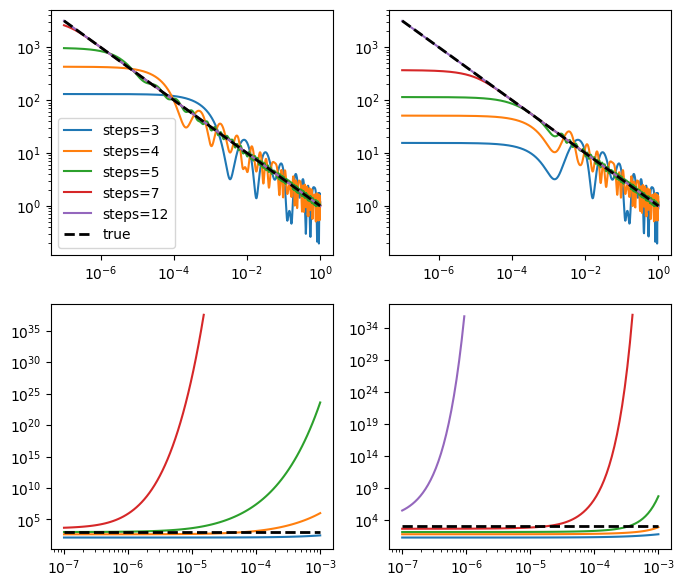

In [7]:
def inv_sqrt(y, shifts):
    steps = len(shifts)
    hs = coeffs_list[:steps] + list( 
        repeat(coeffs_list[-1], steps - len(coeffs_list))
    )
    q = torch.ones_like(y)
    for (a, b, c), shift in zip(hs, shifts):
        y_shifted = (y + shift)/(1+shift)
        r = y_shifted * q**2
        q *= (a + b * r + c * r**2)
    return q

def alt_inv_sqrt(y, shifts, restart=None):
    steps = len(shifts)
    hs = coeffs_list[:steps] + list( 
        repeat(coeffs_list[-1], steps - len(coeffs_list))
    )
    q = torch.ones_like(y) 
    r = y
    for step, ((a, b, c), shift) in enumerate(zip(hs, shifts)):
        if (restart is not None) and (step % restart == 0):
            if step > 0:
                # correct q for previous shift
                # q = q + (prev_shift/2)*q**3
                r = y * q**2
            # prev_shift = shift
        r = (r + shift) / (1 + shift)
        z = (a + b * r + c * r**2)
        r = r * z**2
        # r = r*(1+shift) - shift
        q = q * z
    return q

y = torch.logspace(-7, 0, 1_000)
y_neg = torch.logspace(-7, -3, 100)
fig, axes = plt.subplots(2, 2, figsize=(8, 7), ) # sharey='row'
for step_ix, steps in enumerate([3,4,5,7, 12]):
    no_shift = [0]*steps
    # shift_seq = [2e-3] + [0]*(steps-1)
    shift_seq = list(islice(cycle([2e-3, 0, 0]), steps))
    for shift_ix, (shifts, restart) in enumerate([(no_shift, None), (shift_seq, 3)]):
        axes[0, shift_ix].plot(y.numpy(), alt_inv_sqrt(y, shifts=shifts, restart=restart).numpy(), label=f'steps={steps}')
        axes[1, shift_ix].plot(y_neg.numpy(), alt_inv_sqrt(-y_neg, shifts=shifts, restart=restart).numpy(), color='C'+str(step_ix))

for i in range(2):
    axes[0, i].plot(y, torch.rsqrt(y), label='true', color='black', linewidth=2, linestyle='--')
    axes[1, i].plot(y_neg, 1e3*torch.ones_like(y_neg), label='true', color='black', linewidth=2, linestyle='--')

axes[0, 0].legend()
for ax in axes.flatten():
    ax.set_yscale('log')
    ax.set_xscale('log')

In [89]:
from numpy.polynomial import Polynomial
a, b, c = coeffs_list[-1]
# a, b, c = 1.5, -0.5, 0
p = Polynomial([0, a, 0, b, 0, c])
h = Polynomial([a, b, c])
update = Polynomial.identity() * h**2
xx = torch.concat([-torch.logspace(-0.75, -7, 200), torch.logspace(-7, 0.3, 1000)])
print(h)
print(update)

1.875 - 1.25·x + 0.375·x²
0.0 + 3.515625·x - 4.6875·x² + 2.96875·x³ - 0.9375·x⁴ + 0.140625·x⁵


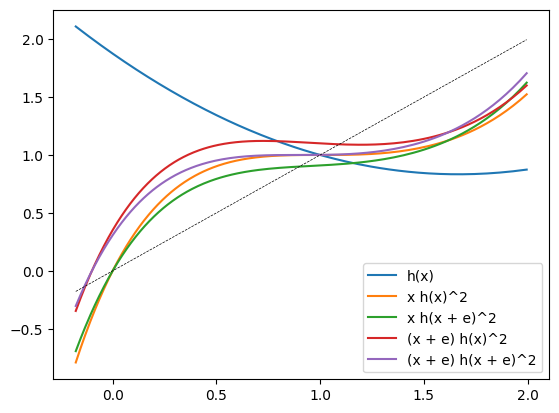

In [90]:
plt.plot(xx, h(xx), label='h(x)')
# plt.plot(xx, h(xx)**2, label='h(x)^2')
plt.plot(xx, xx * h(xx)**2, label='x h(x)^2')
plt.plot(xx, xx * h(xx + 1e-1)**2, label='x h(x + e)^2')
plt.plot(xx, (xx + 1e-1) * h(xx)**2, label='(x + e) h(x)^2')
plt.plot(xx, (xx + 1e-1) * h(xx + 1e-1)**2, label='(x + e) h(x + e)^2')
plt.plot(xx, xx, linestyle='--', linewidth=0.5, c='black')
plt.legend()

In [30]:
y = 1e-1
r = y
for _ in range(10):
    r *= h(r)**2

In [28]:
h(0)

1.875